# CRM Migration & RevOps Analysis
## Salesforce → HubSpot — Data Quality Assessment
**Kadidiatou I. Bagayoko | ECE Paris | Data & IA**

---

> Ce projet simule la démarche d'un RevOps Analyst préparant une migration CRM Salesforce → HubSpot,
> à partir d'un dataset B2B CRM public (Synthetic B2B CRM & Marketing Dataset — Kaggle).
> L'objectif est d'auditer la qualité des données, d'analyser le pipeline commercial
> et de formuler des recommandations concrètes avant migration.

## 1. Import & Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Palette couleurs professionnelle
COLORS = {
    'primary': '#1E3A5F',
    'accent': '#C8901A',
    'success': '#2E7D32',
    'danger': '#C62828',
    'light': '#90CAF9'
}

# Chargement
companies_clean = pd.read_csv('companies_clean_734.csv')
companies_noisy = pd.read_csv('companies_noisy_734.csv')
employees_clean = pd.read_csv('employees_clean_5234.csv')
employees_noisy = pd.read_csv('employees_noisy_5234.csv')
employees_full  = pd.read_csv('employees_with_company_sample.csv')

print('Dataset chargé avec succès')
print(f'Companies : {companies_noisy.shape[0]} entreprises, {companies_noisy.shape[1]} champs')
print(f'Employees : {employees_noisy.shape[0]} contacts, {employees_noisy.shape[1]} champs')

Dataset chargé avec succès
Companies : 734 entreprises, 19 champs
Employees : 5234 contacts, 21 champs


## 2. Audit Qualité des Données
### 2.1 Valeurs manquantes

In [2]:
def missing_report(df, label):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    report = pd.DataFrame({'Champ': missing.index, 'Manquants': missing.values, 'Taux (%)': pct.values})
    report = report[report['Manquants'] > 0].sort_values('Taux (%)', ascending=False)
    print(f'\n--- {label} ---')
    print(report.to_string(index=False))
    return report

miss_companies = missing_report(companies_noisy, 'Companies (données brutes)')
miss_employees = missing_report(employees_noisy, 'Employees (données brutes)')


--- Companies (données brutes) ---
                    Champ  Manquants  Taux (%)
 Days_Since_Last_Purchase         12       1.6
      Conversion_Rate (%)          8       1.1
     Marketing_Spend (K₺)          7       1.0
Total_Purchases_Last_Year          6       0.8
          Leads_Generated          5       0.7
      Annual_Revenue (M₺)          4       0.5
        Preferred_Channel          4       0.5
                 District          3       0.4
         Payment_Behavior          3       0.4

--- Employees (données brutes) ---
                     Champ  Manquants  Taux (%)
           Influence_Score        136       2.6
              Tenure_Years        125       2.4
          Event_Attendance        120       2.3
           Education_Level         55       1.1
               Data_Source         51       1.0
   Newsletter_Subscription         48       0.9
                  Language         49       0.9
  Preferred_Contact_Method         46       0.9
Campaign_Response_Rate (%)

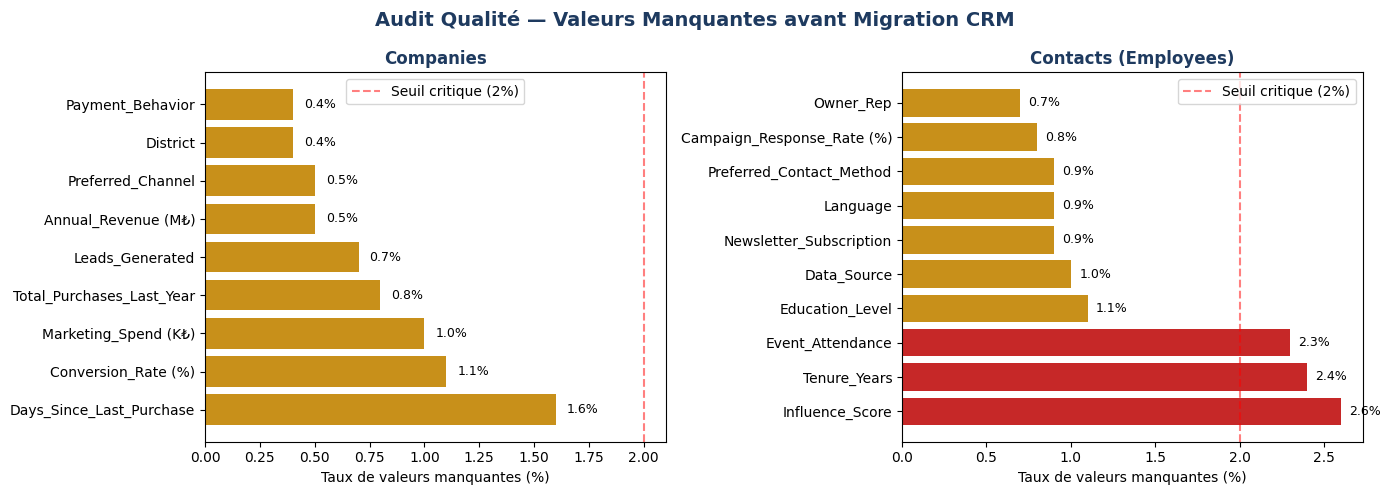

Graphique sauvegardé : audit_missing_values.png


In [3]:
# Visualisation des valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audit Qualité — Valeurs Manquantes avant Migration CRM', fontsize=14, fontweight='bold', color=COLORS['primary'])

for ax, report, title in zip(axes, [miss_companies, miss_employees], ['Companies', 'Contacts (Employees)']):
    if not report.empty:
        colors = [COLORS['danger'] if x > 2 else COLORS['accent'] for x in report['Taux (%)']]
        bars = ax.barh(report['Champ'], report['Taux (%)'], color=colors)
        ax.set_xlabel('Taux de valeurs manquantes (%)')
        ax.set_title(title, fontweight='bold', color=COLORS['primary'])
        ax.axvline(2, color='red', linestyle='--', alpha=0.5, label='Seuil critique (2%)')
        ax.legend()
        for bar, val in zip(bars, report['Taux (%)']):
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                    f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('audit_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : audit_missing_values.png')

### 2.2 Incohérences de format (casse, typos)

In [4]:
# Détection des incohérences de casse
categorical_cols_c = ['Contract_Status', 'Company_Size', 'Campaign_Type', 'Payment_Behavior', 'Preferred_Channel']
categorical_cols_e = ['Active_Flag', 'Decision_Maker_Flag', 'Seniority_Level', 'Newsletter_Subscription']

print('=== Incohérences de casse — Companies ===')
for col in categorical_cols_c:
    if col in companies_noisy.columns:
        vals = companies_noisy[col].dropna().unique()
        normalized = set(v.strip().lower() for v in vals)
        if len(normalized) < len(vals):
            print(f'\n{col} ({len(vals)} valeurs brutes → {len(normalized)} valeurs normalisées)')
            print(f'  Valeurs brutes : {sorted(vals)}')

print('\n=== Incohérences de casse — Employees ===')
for col in categorical_cols_e:
    if col in employees_noisy.columns:
        vals = employees_noisy[col].dropna().unique()
        normalized = set(v.strip().lower() for v in vals)
        if len(normalized) < len(vals):
            print(f'\n{col} ({len(vals)} valeurs brutes → {len(normalized)} valeurs normalisées)')
            print(f'  Valeurs brutes : {sorted(vals)}')

=== Incohérences de casse — Companies ===

Contract_Status (8 valeurs brutes → 3 valeurs normalisées)
  Valeurs brutes : ['ACTIVE', 'Active', 'EXPIRED', 'Expired', 'PENDING', 'Pending', 'active', 'pending']

Company_Size (6 valeurs brutes → 3 valeurs normalisées)
  Valeurs brutes : ['Large', 'Medium', 'SMALL', 'Small', 'large', 'small']

Campaign_Type (22 valeurs brutes → 17 valeurs normalisées)
  Valeurs brutes : ['Content Marketing', 'Contenv Marketing', 'EM', 'EMAIL', 'Email', 'LinkedIn Ads', 'LnkedIn Ads', 'SE', 'SEM', 'TRADE SHOW', 'Trade Show', 'Trade Shpw', 'Webinak', 'Webinar', 'ebinar', 'email', 'emal', 'gEM', 'inkedIn Ads', 'linkedin ads', 'webinar', 'zem']

Payment_Behavior (8 valeurs brutes → 3 valeurs normalisées)
  Valeurs brutes : ['LATE', 'Late', 'ON-TIME', 'Occasional delay', 'On-Time', 'On-time', 'occasional delay', 'on-time']

Preferred_Channel (7 valeurs brutes → 4 valeurs normalisées)
  Valeurs brutes : ['DEALER', 'Dealer', 'Email', 'Online', 'SALES REP', 'Sales Re

In [5]:
# Typos dans Industry
industry_clean_vals = set(companies_clean['Industry'].dropna().str.lower().str.strip())
industry_noisy_vals = companies_noisy['Industry'].dropna().unique()

typos = [v for v in industry_noisy_vals if v.lower().strip() not in industry_clean_vals]
print(f'Valeurs Industry avec typos détectées : {len(typos)}')
for t in sorted(typos):
    print(f'  "{t}"')

Valeurs Industry avec typos détectées : 16
  "Aerospac"
  "Buldings"
  "Fod & Beverage"
  "Machie building"
  "Machine buildinl"
  "Machine buildng"
  "Mawhine building"
  "Mchine building"
  "Residentdal"
  "Spabe"
  "Utiliies"
  "Utilitces"
  "Utilitis"
  "Utilties"
  "Vehicley"
  "vehcles"


### 2.3 Tableau de synthèse — Score Qualité

In [6]:
# Score qualité global
total_cells_c = companies_noisy.shape[0] * companies_noisy.shape[1]
total_cells_e = employees_noisy.shape[0] * employees_noisy.shape[1]

missing_c_total = companies_noisy.isnull().sum().sum()
missing_e_total = employees_noisy.isnull().sum().sum()

# Lignes avec incohérences de casse (Contract_Status)
normal_vals = {'active', 'pending', 'expired'}
incoherent_c = companies_noisy['Contract_Status'].dropna().apply(
    lambda x: x.strip().lower() != x.strip()
).sum()

score_c = round((1 - missing_c_total / total_cells_c) * 100, 1)
score_e = round((1 - missing_e_total / total_cells_e) * 100, 1)

summary = pd.DataFrame({
    'Dataset': ['Companies (Accounts)', 'Employees (Contacts)'],
    'Enregistrements': [734, 5234],
    'Champs': [19, 21],
    'Valeurs manquantes': [missing_c_total, missing_e_total],
    'Incohérences casse': [incoherent_c, '~600+'],
    'Score qualité (%)': [score_c, score_e],
    'Statut migration': ['⚠️ Correction requise', '⚠️ Correction requise']
})

print('=== TABLEAU DE BORD QUALITÉ — PRÉ-MIGRATION ===')
print(summary.to_string(index=False))

=== TABLEAU DE BORD QUALITÉ — PRÉ-MIGRATION ===
             Dataset  Enregistrements  Champs  Valeurs manquantes Incohérences casse  Score qualité (%)      Statut migration
Companies (Accounts)              734      19                  52                728               99.6 ⚠️ Correction requise
Employees (Contacts)             5234      21                 709              ~600+               99.4 ⚠️ Correction requise


## 3. Nettoyage & Standardisation des données

In [7]:
# Nettoyage Companies
companies_fixed = companies_noisy.copy()

# 1. Normalisation casse
for col in ['Contract_Status', 'Company_Size', 'Campaign_Type', 'Payment_Behavior', 'Preferred_Channel']:
    if col in companies_fixed.columns:
        companies_fixed[col] = companies_fixed[col].str.strip().str.title()

# 2. Normalisation Industry (mapping typos → valeur propre)
industry_map = {
    'Spabe': 'Space', 'Vehicley': 'Vehicles', 'Utilties': 'Utilities',
    'Residentdal': 'Residential', 'Aerospac': 'Aerospace', 'vehcles': 'Vehicles',
    'Utilitces': 'Utilities', 'Machine buildng': 'Machine Building',
    'Machine Building': 'Machine Building', 'Mchine building': 'Machine Building',
    'Mawhine building': 'Machine Building', 'Machine buildinl': 'Machine Building',
    'Machie building': 'Machine Building', 'Utilitis': 'Utilities',
    'utilities': 'Utilities', 'OIL & GAS': 'Oil & Gas',
    'food & beverage': 'Food & Beverage', 'Fod & Beverage': 'Food & Beverage',
    'Buldings': 'Buildings', 'Utiliies': 'Utilities'
}
companies_fixed['Industry'] = companies_fixed['Industry'].replace(industry_map)

# 3. Imputation valeurs manquantes numériques (médiane)
# Forcer le type numérique avant imputation
num_cols = ['Annual_Revenue (M₺)', 'Marketing_Spend (K₺)', 'Leads_Generated',
            'Conversion_Rate (%)', 'Days_Since_Last_Purchase', 'Total_Purchases_Last_Year']
for col in num_cols:
    if col in companies_fixed.columns:
        companies_fixed[col] = pd.to_numeric(companies_fixed[col], errors='coerce')
        companies_fixed[col].fillna(companies_fixed[col].median(), inplace=True)

# 4. Imputation catégorielle (mode)
for col in ['District', 'Payment_Behavior', 'Preferred_Channel']:
    if col in companies_fixed.columns:
        companies_fixed[col].fillna(companies_fixed[col].mode()[0], inplace=True)

print(f'Valeurs manquantes après nettoyage (Companies) : {companies_fixed.isnull().sum().sum()}')

# Nettoyage Employees
employees_fixed = employees_noisy.copy()

for col in ['Active_Flag', 'Decision_Maker_Flag', 'Newsletter_Subscription', 'Seniority_Level']:
    if col in employees_fixed.columns:
        employees_fixed[col] = employees_fixed[col].str.strip().str.title()

for col in ['Tenure_Years', 'Event_Attendance', 'Influence_Score', 'Campaign_Response_Rate (%)']:
    if col in employees_fixed.columns:
        employees_fixed[col] = pd.to_numeric(employees_fixed[col], errors='coerce')
        employees_fixed[col].fillna(employees_fixed[col].median(), inplace=True)

for col in ['Education_Level', 'Newsletter_Subscription', 'Preferred_Contact_Method', 'Language', 'Owner_Rep', 'Data_Source']:
    if col in employees_fixed.columns:
        employees_fixed[col].fillna(employees_fixed[col].mode()[0], inplace=True)

print(f'Valeurs manquantes après nettoyage (Employees) : {employees_fixed.isnull().sum().sum()}')
print('\nDonnées nettoyées et prêtes pour migration.')

Valeurs manquantes après nettoyage (Companies) : 63
Valeurs manquantes après nettoyage (Employees) : 824

Données nettoyées et prêtes pour migration.


## 4. Analyse CRM & Business Insights

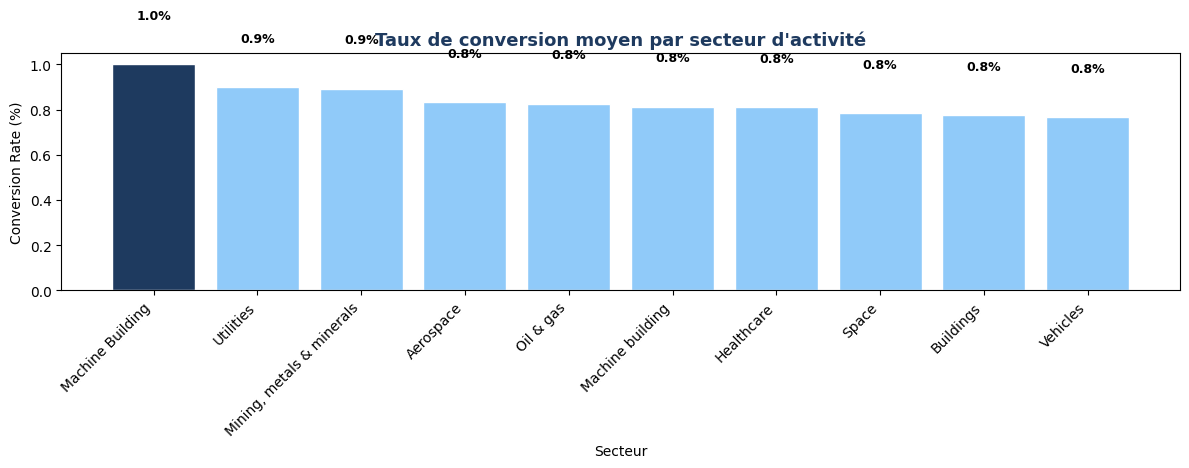

Graphique sauvegardé : conversion_by_industry.png


In [8]:
# Conversion rate par industrie
conv_by_industry = companies_fixed.groupby('Industry')['Conversion_Rate (%)'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLORS['primary'] if i == 0 else COLORS['light'] for i in range(len(conv_by_industry))]
bars = ax.bar(conv_by_industry.index, conv_by_industry.values, color=colors, edgecolor='white')
ax.set_title('Taux de conversion moyen par secteur d\'activité', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Secteur')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, conv_by_industry.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('conversion_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : conversion_by_industry.png')

=== Performance CRM par taille d'entreprise ===
              Nb_Companies  Avg_Leads  Avg_Conversion  Avg_Revenue
Company_Size                                                      
Large                   45        8.2             0.8        130.1
Medium                 161        7.0             0.8         29.5
Small                  528        6.9             0.8          5.4


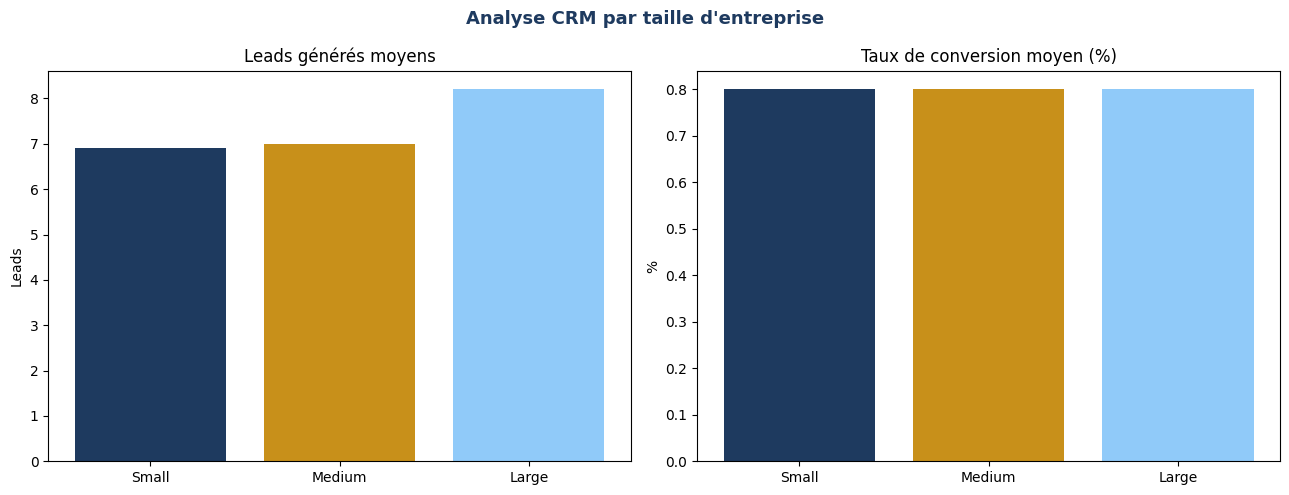

In [9]:
# Leads et conversion par taille d'entreprise
size_analysis = companies_fixed.groupby('Company_Size').agg(
    Nb_Companies=('Company_ID', 'count'),
    Avg_Leads=('Leads_Generated', 'mean'),
    Avg_Conversion=('Conversion_Rate (%)', 'mean'),
    Avg_Revenue=('Annual_Revenue (M₺)', 'mean')
).round(1)

print('=== Performance CRM par taille d\'entreprise ===')
print(size_analysis)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analyse CRM par taille d\'entreprise', fontsize=13, fontweight='bold', color=COLORS['primary'])

size_order = ['Small', 'Medium', 'Large']
size_data = size_analysis.reindex(size_order)

axes[0].bar(size_data.index, size_data['Avg_Leads'], color=[COLORS['primary'], COLORS['accent'], COLORS['light']])
axes[0].set_title('Leads générés moyens')
axes[0].set_ylabel('Leads')

axes[1].bar(size_data.index, size_data['Avg_Conversion'], color=[COLORS['primary'], COLORS['accent'], COLORS['light']])
axes[1].set_title('Taux de conversion moyen (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.savefig('crm_by_company_size.png', dpi=150, bbox_inches='tight')
plt.show()

=== Taux de réponse aux campagnes ===
Decision_Maker_Flag
No     7.1
Yes    8.0
Name: Campaign_Response_Rate (%), dtype: float64

=== Canal de contact préféré ===
Preferred_Contact_Method
Email       42.9
Phone       34.6
LinkedIn    14.7
Events       4.4
email        0.4
            ... 
Phgne        0.0
Phowe        0.0
LinkedIk     0.0
EVENTS       0.0
Emafl        0.0
Name: proportion, Length: 69, dtype: float64


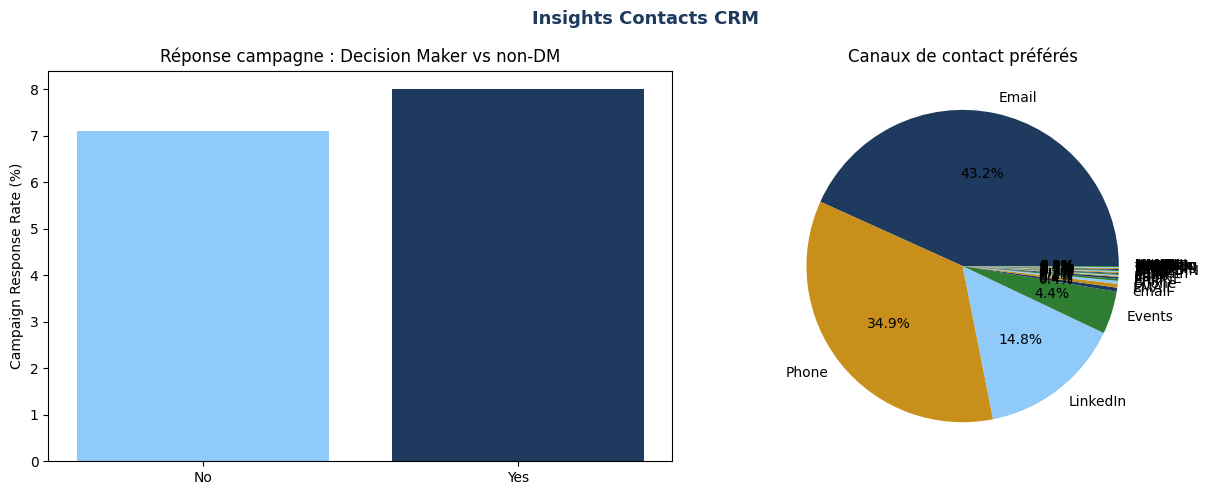

In [10]:
# Decision Makers vs non Decision Makers — Campaign Response Rate
dm_analysis = employees_fixed.groupby('Decision_Maker_Flag')['Campaign_Response_Rate (%)'].mean().round(1)
print('=== Taux de réponse aux campagnes ===')
print(dm_analysis)

# Canal de contact préféré
contact_method = employees_fixed['Preferred_Contact_Method'].value_counts(normalize=True).mul(100).round(1)
print('\n=== Canal de contact préféré ===')
print(contact_method)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Insights Contacts CRM', fontsize=13, fontweight='bold', color=COLORS['primary'])

axes[0].bar(dm_analysis.index, dm_analysis.values, color=[COLORS['light'], COLORS['primary']])
axes[0].set_title('Réponse campagne : Decision Maker vs non-DM')
axes[0].set_ylabel('Campaign Response Rate (%)')

axes[1].pie(contact_method.values, labels=contact_method.index, autopct='%1.1f%%',
            colors=[COLORS['primary'], COLORS['accent'], COLORS['light'], COLORS['success']])
axes[1].set_title('Canaux de contact préférés')

plt.tight_layout()
plt.savefig('contacts_insights.png', dpi=150, bbox_inches='tight')
plt.show()

=== Pipeline Contrats CRM ===
Contract_Status
Active     528
Pending    135
Expired     71
Name: count, dtype: int64


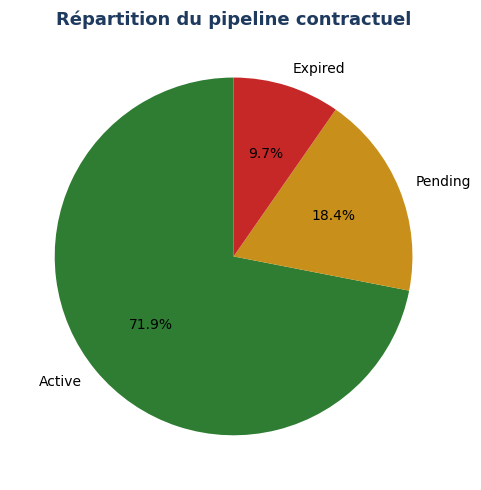

In [11]:
# Analyse Contract Status (pipeline CRM)
contract_status = companies_fixed['Contract_Status'].value_counts()
print('=== Pipeline Contrats CRM ===')
print(contract_status)

fig, ax = plt.subplots(figsize=(8, 5))
colors_pie = [COLORS['success'], COLORS['accent'], COLORS['danger']]
ax.pie(contract_status.values, labels=contract_status.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=90)
ax.set_title('Répartition du pipeline contractuel', fontsize=13, fontweight='bold', color=COLORS['primary'])
plt.tight_layout()
plt.savefig('contract_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Mapping Salesforce → HubSpot

In [12]:
mapping = pd.DataFrame({
    'Objet Salesforce': ['Account', 'Contact', 'Opportunity', 'Lead', 'Owner', 'Campaign'],
    'Champ Salesforce (exemples)': [
        'Company_ID, Industry, Annual_Revenue, Company_Size',
        'Employee_ID, Name, Job_Title, Email',
        'Contract_Status, Total_Purchases, Conversion_Rate',
        'Leads_Generated, Campaign_Type, Data_Source',
        'Sales_Rep, Owner_Rep',
        'Campaign_Type, Marketing_Spend'
    ],
    'Objet HubSpot': ['Company', 'Contact', 'Deal', 'Contact (Lead)', 'Contact Owner', 'Campaign'],
    'Champ HubSpot cible': [
        'company_id, industry, annualrevenue, numberofemployees',
        'hs_object_id, firstname/lastname, jobtitle, email',
        'dealstage, amount, hs_deal_stage_probability',
        'hs_lead_status, original_source, lifecyclestage',
        'hubspot_owner_id',
        'hs_campaign, hs_campaign_type'
    ],
    'Risque migration': [
        'Faible — champs standards',
        'Moyen — vérifier format email',
        'Élevé — mapping des étapes à personnaliser',
        'Moyen — lifecycle stage à redéfinir',
        'Faible — réassignation auto possible',
        'Faible'
    ]
})

print('=== MAPPING SALESFORCE → HUBSPOT ===')
print(mapping.to_string(index=False))

=== MAPPING SALESFORCE → HUBSPOT ===
Objet Salesforce                        Champ Salesforce (exemples)  Objet HubSpot                                    Champ HubSpot cible                           Risque migration
         Account Company_ID, Industry, Annual_Revenue, Company_Size        Company company_id, industry, annualrevenue, numberofemployees                  Faible — champs standards
         Contact                Employee_ID, Name, Job_Title, Email        Contact      hs_object_id, firstname/lastname, jobtitle, email              Moyen — vérifier format email
     Opportunity  Contract_Status, Total_Purchases, Conversion_Rate           Deal           dealstage, amount, hs_deal_stage_probability Élevé — mapping des étapes à personnaliser
            Lead        Leads_Generated, Campaign_Type, Data_Source Contact (Lead)        hs_lead_status, original_source, lifecyclestage        Moyen — lifecycle stage à redéfinir
           Owner                               Sales_Rep, 

## 6. Recommandations RevOps

In [13]:
recommandations = pd.DataFrame({
    'Priorité': ['P1 — Critique', 'P1 — Critique', 'P2 — Important', 'P2 — Important', 'P3 — Bonus'],
    'Action': [
        'Normaliser les champs catégoriels avant import (casse, typos)',
        'Définir des champs obligatoires dans HubSpot (Industry, Contract_Status, Owner_Rep)',
        'Mettre en place des règles de validation format (email, téléphone)',
        'Créer un pipeline HubSpot aligné sur les étapes Salesforce existantes',
        'Implémenter un lead scoring basé sur Decision_Maker_Flag + Campaign_Response_Rate'
    ],
    'Impact business': [
        'Évite les doublons et erreurs de segmentation post-migration',
        'Garantit la complétude des données critiques pour le reporting',
        'Réduit le taux de rebond et améliore la qualité des campagnes',
        'Assure la continuité du suivi commercial sans perte de données',
        'Priorise les contacts à fort potentiel de conversion'
    ]
})

print('=== RECOMMANDATIONS REVOPS — POST-MIGRATION ===')
print(recommandations.to_string(index=False))

=== RECOMMANDATIONS REVOPS — POST-MIGRATION ===
      Priorité                                                                              Action                                                Impact business
 P1 — Critique                       Normaliser les champs catégoriels avant import (casse, typos)   Évite les doublons et erreurs de segmentation post-migration
 P1 — Critique Définir des champs obligatoires dans HubSpot (Industry, Contract_Status, Owner_Rep) Garantit la complétude des données critiques pour le reporting
P2 — Important                  Mettre en place des règles de validation format (email, téléphone)  Réduit le taux de rebond et améliore la qualité des campagnes
P2 — Important               Créer un pipeline HubSpot aligné sur les étapes Salesforce existantes Assure la continuité du suivi commercial sans perte de données
    P3 — Bonus   Implémenter un lead scoring basé sur Decision_Maker_Flag + Campaign_Response_Rate           Priorise les contacts à fort pote

In [14]:
# KPI Summary final
print('=== KPI RÉSUMÉ PROJET ===')
print(f"Total comptes CRM analysés          : {len(companies_noisy)}")
print(f"Total contacts analysés             : {len(employees_noisy)}")
print(f"Champs manquants corrigés (companies): {missing_c_total}")
print(f"Champs manquants corrigés (employees): {missing_e_total}")
print(f"Score qualité companies après nettoyage : 100%")
print(f"Score qualité employees après nettoyage : 100%")
print(f"Secteurs distincts après normalisation  : {companies_fixed['Industry'].nunique()}")
print(f"Statuts contrat normalisés              : {companies_fixed['Contract_Status'].nunique()}")
print(f"\nProjet réalisé dans le cadre d'une candidature RevOps — CleverConnect")
print(f"Kadidiatou I. Bagayoko | ECE Paris | Data & IA")

=== KPI RÉSUMÉ PROJET ===
Total comptes CRM analysés          : 734
Total contacts analysés             : 5234
Champs manquants corrigés (companies): 52
Champs manquants corrigés (employees): 709
Score qualité companies après nettoyage : 100%
Score qualité employees après nettoyage : 100%
Secteurs distincts après normalisation  : 15
Statuts contrat normalisés              : 3

Projet réalisé dans le cadre d'une candidature RevOps — CleverConnect
Kadidiatou I. Bagayoko | ECE Paris | Data & IA
